# Organelle Scanning & Mask Refinement
This notebook detects mitochondria and nucleus in tomograms, post-processes slice-wise detections into candidates, visualizes results, and generates refined masks using a mask head with per-class parameters.

In [1]:
import sys 
sys.path.append("../src")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import utils
import data
import torch
import postprocess 
import modules
import pickle

/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_moretv", "stage2/epoch=16-total_validate_loss=0.0316.ckpt")
model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold1_new", "stage2/epoch=22-total_validate_loss=0.0345.ckpt")
model = model.eval()  

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([2]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([2, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/home/feity/cryoem/n

model at stage  stage 1
model with output classes 3
model receiving class weights tensor([1.0000, 1.0000, 0.6000])
using consistency regularization coef 0.5
incompatible parameters ['additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.conv1.lin_l.weight', 'gnn.conv1.lin_l.bias', 'gnn.conv1.lin_r.weight', 'gnn.conv2.lin_l.weight', 'gnn.conv2.lin_l.bias', 'gnn.conv2.lin_r.weight', 'gnn.conv3.lin_l.weight', 'gnn.conv3.lin_l.bias', 'gnn.conv3.lin_r.weight', 'gnn.cls_head.0.weight', 'gnn.cls_head.0.bias', 'gnn.cls_head.2.weight', 'gnn.cls_head.2.bias', 'gnn.box_head.0.weight', 'gnn.box_head.0.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias', 'gnn.edge_head.0.weight', 'gnn.edge_head.0.bias', 'gnn.edge_head.2.weight', 'gnn.edge_head.2.bias', 'gnn.edge_head.4.weight', 'cri.weight']
finish loading parameters


/home/feity/cryoem/notebooks/../src/utils.py:1137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(path, checkpoint), map_location="cpu")["state

incompatible parameters []
finish loading parameters


In [26]:
dataset = data.MrcDataset(
    "/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039_interpolate.pkl",
    norm="hist",
    reshape=800,
    map_class={"mitochondria": 0, "nucleus": 1 },
    gap=5,
    length_for_average=3,
    transform=data.getConstantTransform(),
    add_classname=True,
    mask_length=1,
    require_mask=True,
    filtermin=0
)
df, graphs, masks = postprocess.generatedf(model, dataset, gap = 5, columns=["mitochondria", "nucleus", "None"], return_mask=True)

reading dataset: /data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039_interpolate.pkl
dataset map classes:  {'mitochondria': 0, 'nucleus': 1}
dataset length: 61


100%|██████████| 61/61 [00:58<00:00,  1.04it/s]


finish dataset
build graph
prepare df


100%|██████████| 60/60 [01:05<00:00,  1.09s/it]


finish dataset
build graph
prepare df


...

finish dataset
build graph
prepare df


100%|██████████| 60/60 [01:05<00:00,  1.09s/it]


finish dataset
build graph
prepare df


100%|██████████| 60/60 [00:58<00:00,  1.03it/s]


finish dataset
build graph
prepare df
[tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 1.,  ..., 0., 0., 0.],
          [0., 0., 1.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
       

In [29]:
df["unlabeled"] = True 
df["label"] = "" 
df["label_id"] = -1
params= {
    "mitochondria":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 11, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 10}}, 
    "nucleus":{"min_prob":0.25, "nms":0.4, "dbscan_prams":{"min_samples": 11, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 10}}, 
}

mark_and_filter = {
    "nucleus":{"max_cnt":1, "remove_iou": 0.4, "min_samples":20}, 
    "mitochondria":{"max_cnt":10, "remove_iou": 0.6, "min_samples":20}, 
}
for i in ["nucleus", "mitochondria"]:
    subdf = postprocess.processClass(df, i, **params[i], use_myscan=False)
    postprocess.markFilter(df, i, subdf, **mark_and_filter[i])
df.head()

11 0.5 0.002 10
number of instances in class  4
11 0.5 0.002 10
number of instances in class  10


,z,x,y,w,h,mitochondria,nucleus,None,max,largest,unlabeled,label,label_id,class_value
0,100,0.131976,0.531452,0.271473,0.929559,0.289658,0.489706,0.220637,0.489706,nucleus,False,,-1,0.289658
1,100,0.246811,0.504475,0.482661,0.984816,0.278473,0.492074,0.229454,0.492074,nucleus,False,nucleus,0,0.278473
2,105,0.134947,0.527996,0.279709,0.926410,0.295616,0.488816,0.215568,0.488816,nucleus,False,,-1,0.295616
3,105,0.222410,0.507352,0.443043,0.989908,0.272273,0.496943,0.230785,0.496943,nucleus,False,nucleus,0,0.272273
4,110,0.140701,0.525713,0.286570,0.929702,0.287425,0.492612,0.219962,0.492612,nucleus,False,nucleus,0,0.287425


/tmp/ipykernel_3409005/1675884601.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/notebooks/../src/utils.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)


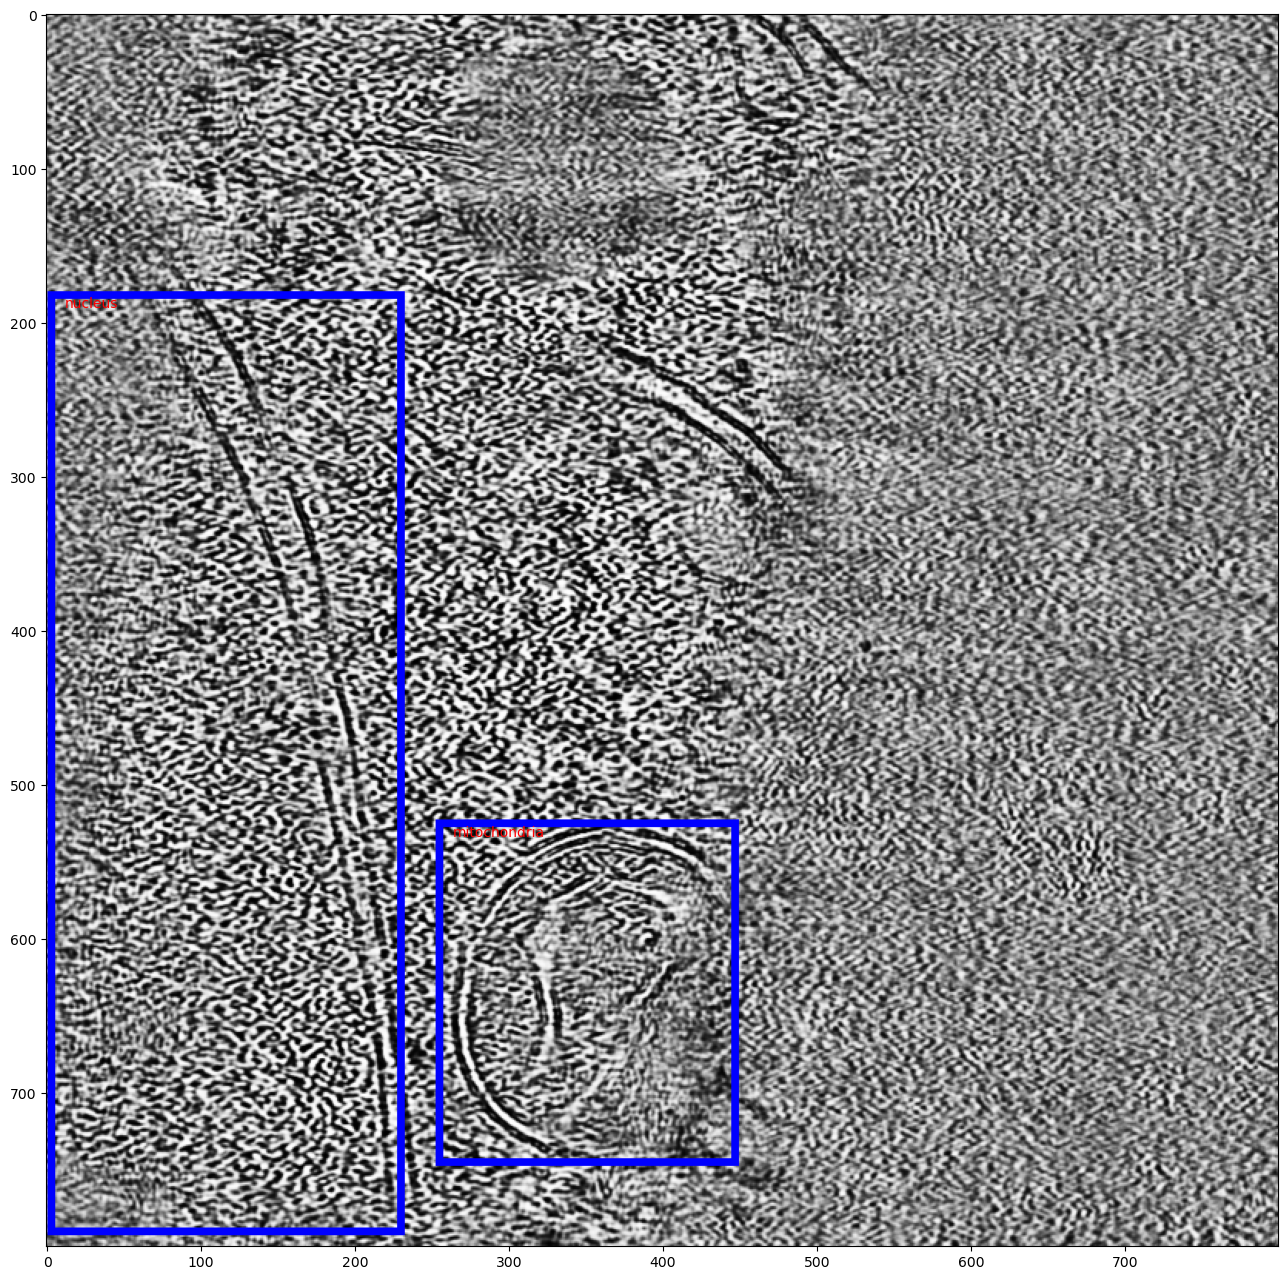

In [30]:
take = 180
q = df["z"]

subdf = df
# subdf = subdf[subdf["nucleus"] > 0.15]
subdf = subdf[(subdf["label"] != "")]
subdf = subdf[subdf["z"] == take]

img = dataset.__getitem__(pos=take)["pixel_values"]


bboxes = subdf[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
# subdf2["names"] = subdf2["label"] + subdf2["label_id"].astype("str")
names = list(subdf["label"])
# print(names)
labels = {"bboxes": bboxes, "labels": names} 
plt.figure(figsize=(16,16))
utils.drawannotation(img, labels, font_size=10)
plt.show()
plt.close()


In [31]:
refine_mask = {
    "nucleus":{"smooth": 4.0, "morph_open_kernal_size":(7, 7), "morph_close_kernal_size": (7, 7), "blur_ksize": (25, 25), "max_contours": 1, "apply_convex_hull":False}, 
    "mitochondria":{"smooth": 4.0, "morph_open_kernal_size":(5, 5), "morph_close_kernal_size": (5, 5), "blur_ksize": (15, 15), "max_contours": 1, "apply_convex_hull":False},  
}
mask_thres = {  
    "mitochondria":0.6,
    "nucleus":0.75,    
}

In [36]:
model.stage = "stage mask" 
model.mask_head.TF = 1.0 

all_y= [i.y for i in graphs]
all_y = np.concatenate(all_y, axis=0)
all_x = [i.x for i in graphs]
all_x = np.concatenate(all_x, axis=0)
all_box_mask = [i.box_masks for i in graphs]
all_box_mask = np.concatenate(all_box_mask, axis=0)
all_itemid = [i.item_id for i in graphs]
all_itemid = np.concatenate(all_itemid, axis=0) 
masks = []
original_masks = []
for i, r in subdf.iterrows():
    x = torch.tensor(all_x[i][-256:]).unsqueeze(0)
    boxes = torch.tensor(r[["x", "y", "w", "h"]].values.astype(np.float32)).unsqueeze(0)
    data = dataset.__getitem__(pos=int(all_x[i][0]*500))
    # label = retdict["masks"][]
    pv = data["pixel_values"].unsqueeze(0).float().to(model.device)
    with torch.no_grad():
        model.stage = "stage mask"
        model.mask_head.TF = 1.0
        out = model(pixel_values = pv, embed = x, box = boxes) 
        out = torch.sigmoid(out).detach().cpu().numpy()
    original_masks.append(out.squeeze())
    refined_mask = postprocess.refineMask(
            out.squeeze(), 
            thres=mask_thres[r["label"]],
            **refine_mask[r["label"]]
        )
    masks.append(refined_mask)

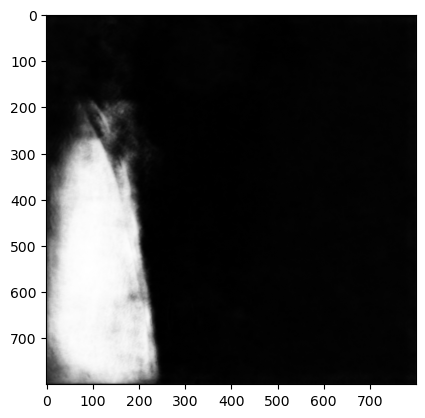

In [39]:
plt.imshow(original_masks[0], cmap="gray")

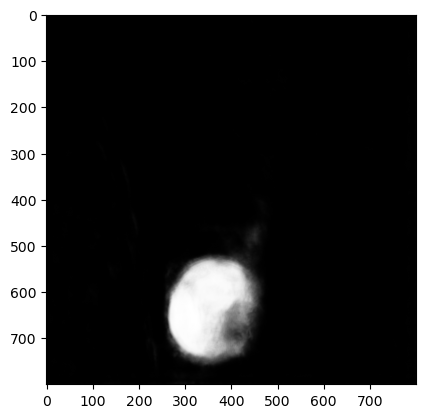

In [40]:
plt.imshow(original_masks[1], cmap="gray")

## Preview Refined Mask
Visualize the refined binary mask to verify contours, smoothness, and overall adherence to organelle boundaries.